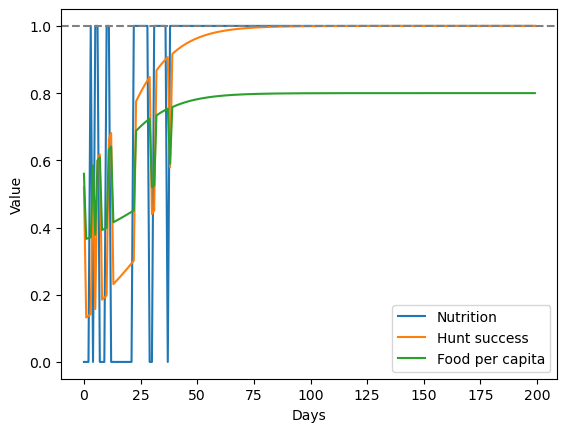

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# set params
#a. Number of males and females
Nm, Nf = 10, 10
# b. feedback on skill
alpha_0, alpha_1 = 0.1, 0.05
# c. params in the logistic function 
theta0, theta1, theta2 = -2, 0.8, 2.0
# d. gatherer productivity and variance
mu0, mu1, sigma = 0.6, 0.6, 0.1
#
rho = 0.5
# f. number of days
T = 200  

# Initialize
k = 0.1  
n = 1.0  
# make list to store errythang
k_hist, n_hist, p_hist, f_hist = [], [], [], []

for t in range(T):
    # logistic success probability
    p = 1 / (1 + np.exp(-(theta0 + theta1 * k + theta2 * n)))

    # H ~ Bernoulli(p)
    H = np.random.binomial(1, p)
    
    # mean gatherer productivity (fork function)
    mu = mu0 if H==1 else mu1
   
    # expected food per capita
    f = (Nm * p + Nf * mu) / (Nm + Nf)
   
    # update skill and nutrition
    k = k + alpha_0*H+ alpha_1*(1 - H)
    # n is 1 if H =1 and 0 otherwise
    n = 1 if H == 1 else 0
    # store for plotting
    k_hist.append(k)
    n_hist.append(n)
    p_hist.append(p)
    f_hist.append(f)

# Plot trajectories
plt.figure()
#plt.plot(k_hist, label='Skill')
plt.plot(n_hist, label='Nutrition')
plt.plot(p_hist, label='Hunt success')
plt.plot(f_hist, label='Food per capita')
plt.axhline(1, color='grey', linestyle='--')
plt.legend()
plt.xlabel('Days')
plt.ylabel('Value')
plt.show()

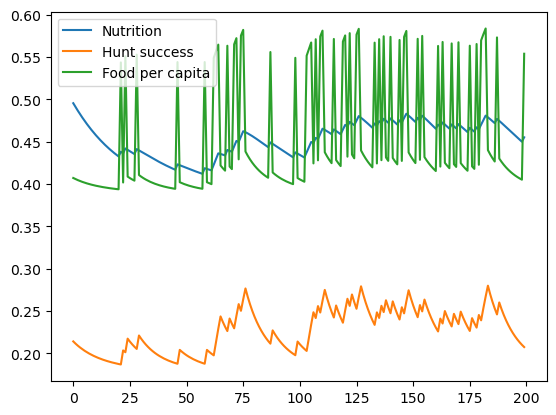

In [8]:
import numpy as np
import matplotlib.pyplot as plt

Nm, Nf = 10, 10

alpha = 0.1       # skill learning rate
beta = 0.05       # nutrition accumulation rate
decay = 0.95      # nutrition decay factor

theta0, theta1, theta2 = -2, 1.0, 1.2

mu0, mu1, sigma = 0.6, 0.6, 0.1

T = 200

k = 0.1
n = 0.5

k_hist, n_hist, p_hist, f_hist = [], [], [], []

for t in range(T):
    
    p = 1 / (1 + np.exp(-(theta0 + theta1 * k + theta2 * n)))
    
    H = np.random.binomial(1, p)
    
    mu = mu0 if H == 1 else mu1
    
    # cooperation: hunters share part of the gain with gatherers
    cooperation_bonus = 0.3 * H
    
    f = (Nm * (p + cooperation_bonus) + Nf * mu) / (Nm + Nf)
    
    # bounded skill learning
    k = k + alpha * (H - k)       # moves toward 1 if successful, toward 0 if failing
    
    # smooth nutrition
    n = decay * n + beta * f      # accumulates with food
    
    k_hist.append(k)
    n_hist.append(n)
    p_hist.append(p)
    f_hist.append(f)

plt.plot(n_hist, label="Nutrition")
plt.plot(p_hist, label="Hunt success")
plt.plot(f_hist, label="Food per capita")
plt.legend()
plt.show()

